# Đồ án KTDL - Mô hình Residual CNN bổ sung

Notebook này là nhánh mô hình deep learning bổ sung cho pipeline `FgMDM + stacking`.

Mục tiêu:
- dùng trực tiếp các ma trận connectivity đã tính sẵn trong `Super_MultiDomain_Features_Role3`
- xếp nhiều feature thành tensor nhiều kênh dạng `n_samples x n_features x 19 x 19`
- chia train/validation/test theo subject để tránh data leakage
- train mô hình Residual CNN nhỏ bằng PyTorch
- đánh giá ở subject-level bằng `ROC-AUC`, `Accuracy`, `F1`, `Sensitivity`, `Specificity`

Lưu ý: đây là mô hình bổ sung để so sánh, không thay thế flow chính trong paper. Dataset nhỏ nên deep learning dễ overfit; kết quả cần được trình bày như baseline/thử nghiệm mở rộng.


## 1. Import thư viện

Cell này nạp các thư viện xử lý dữ liệu, PyTorch và metric đánh giá.


In [1]:
from pathlib import Path
import json
import os
import random
import warnings

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')


## 2. Cấu hình notebook

Bạn có thể đổi `SELECTED_PROBLEM` để chạy từng bài toán nhị phân. Các bài toán dùng cùng quy ước với notebook LOSOCV:
- `ad_hc`: AD là lớp dương
- `ftd_hc`: FTD là lớp dương
- `ftd_ad`: FTD là lớp dương, AD là lớp âm


In [2]:
ROOT = Path('/home/dohaidang/DataMining_Project')
PRECOMPUTED_DIR = ROOT / 'Super_MultiDomain_Features_Role3'
OUTPUT_DIR = ROOT / 'notebook_outputs'
OUTPUT_DIR.mkdir(exist_ok=True)
OUTPUT_TAG = 'super_multidomain'

RANDOM_STATE = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

PROBLEMS = {
    'ad_hc': ('A', 'C', 'AD', 'HC'),
    'ftd_hc': ('F', 'C', 'FTD', 'HC'),
    'ftd_ad': ('F', 'A', 'FTD', 'AD'),
}

SELECTED_PROBLEM = 'ad_hc'
SUPER_BANDS = ('delta', 'theta', 'alpha', 'beta', 'gamma')
SUPER_METRICS = ('cov', 'corr', 'plv', 'coh', 'csd', 'mi')
SELECTED_FEATURES = [
    f'{band}_{metric}'
    for band in SUPER_BANDS
    for metric in SUPER_METRICS
]

TEST_SIZE = 0.20
VAL_SIZE = 0.20
BATCH_SIZE = 128
MAX_EPOCHS = 60
PATIENCE = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
DROPOUT = 0.35

print('Device:', DEVICE)


Device: cuda


## 3. Seed để tái lập kết quả

Cell này cố định random seed cho `numpy`, `random` và `torch`.


In [3]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(RANDOM_STATE)


## 4. Nạp dữ liệu multi-channel connectivity

Mỗi feature là một ma trận `19 x 19`. Notebook stack 8 feature thành input giống ảnh nhiều kênh:

`X shape = (n_epoch, 8, 19, 19)`


In [4]:
def normalize_subject_ids(subject_ids: np.ndarray) -> np.ndarray:
    normalized = []
    for subject_id in subject_ids.astype(str):
        if subject_id.startswith('sub-'):
            normalized.append(subject_id)
        else:
            normalized.append(f'sub-{subject_id.zfill(3)}')
    return np.asarray(normalized)


def discover_multichannel_features(precomputed_dir: Path, feature_names: list[str]) -> list[str]:
    missing = [name for name in feature_names if not (precomputed_dir / f'{name}.npy').exists()]
    if missing:
        raise FileNotFoundError(f'Missing feature files: {missing[:5]}')
    return feature_names


def load_multichannel_features(precomputed_dir: Path, feature_names: list[str]):
    labels = np.load(precomputed_dir / 'labels.npy', allow_pickle=True).astype(str)
    subject_ids = normalize_subject_ids(np.load(precomputed_dir / 'subject_ids.npy', allow_pickle=True))
    feature_names = discover_multichannel_features(precomputed_dir, feature_names)
    channels = []
    for feature_name in feature_names:
        feature_path = precomputed_dir / f'{feature_name}.npy'
        matrix = np.load(feature_path, allow_pickle=True).astype(np.float32)
        matrix = np.nan_to_num(matrix, nan=0.0, posinf=0.0, neginf=0.0)
        channels.append(matrix)
    X = np.stack(channels, axis=1).astype(np.float32)
    return X, labels, subject_ids

X_all, labels_all, subject_ids_all = load_multichannel_features(PRECOMPUTED_DIR, SELECTED_FEATURES)
print('X_all:', X_all.shape)
print('n_features:', len(SELECTED_FEATURES))
print('features:', SELECTED_FEATURES)
print('labels:', pd.Series(labels_all).value_counts().to_dict())
print('subjects:', len(np.unique(subject_ids_all)))


X_all: (13422, 8, 19, 19)
labels: {'A': 5666, 'C': 4603, 'F': 3153}
subjects: 88


## 5. Tạo bài toán nhị phân và chia subject-level

Không chia ngẫu nhiên theo epoch. Tất cả epoch của một subject phải nằm cùng một tập `train`, `validation` hoặc `test`.


In [5]:
def make_binary_problem(X, labels, subject_ids, problem_name: str):
    positive_code, negative_code, positive_name, negative_name = PROBLEMS[problem_name]
    mask = np.isin(labels, [positive_code, negative_code])
    X_bin = X[mask]
    y_bin = (labels[mask] == positive_code).astype(np.int64)
    s_bin = subject_ids[mask]
    return X_bin, y_bin, s_bin, positive_name, negative_name


def build_subject_table(y: np.ndarray, subject_ids: np.ndarray) -> pd.DataFrame:
    frame = pd.DataFrame({'subject_id': subject_ids, 'label': y})
    subject_frame = frame.drop_duplicates('subject_id').sort_values('subject_id').reset_index(drop=True)
    counts = frame.groupby('subject_id').size().rename('epoch_count')
    return subject_frame.merge(counts, on='subject_id', how='left')


def split_subjects(subject_table: pd.DataFrame):
    train_val, test = train_test_split(
        subject_table,
        test_size=TEST_SIZE,
        stratify=subject_table['label'],
        random_state=RANDOM_STATE,
    )
    train, val = train_test_split(
        train_val,
        test_size=VAL_SIZE,
        stratify=train_val['label'],
        random_state=RANDOM_STATE,
    )
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)

X_problem, y_problem, s_problem, positive_name, negative_name = make_binary_problem(
    X_all, labels_all, subject_ids_all, SELECTED_PROBLEM
)
subject_table = build_subject_table(y_problem, s_problem)
train_subjects, val_subjects, test_subjects = split_subjects(subject_table)

print('Problem:', SELECTED_PROBLEM, f'({positive_name} vs {negative_name})')
display(subject_table['label'].value_counts().rename('subject_count').to_frame())
display(pd.DataFrame({
    'split': ['train', 'val', 'test'],
    'n_subjects': [len(train_subjects), len(val_subjects), len(test_subjects)],
    'positive_subjects': [train_subjects.label.sum(), val_subjects.label.sum(), test_subjects.label.sum()],
}))


Problem: ad_hc (AD vs HC)


,subject_count
label,
1,36
0,29


,split,n_subjects,positive_subjects
0,train,41,23
1,val,11,6
2,test,13,7


## 6. Chuẩn hóa dữ liệu theo train set

CNN nhạy với scale. Cell này fit mean/std trên train epoch rồi áp dụng cho validation/test.


In [6]:
def subset_by_subjects(X, y, subject_ids, selected_subjects):
    selected = set(selected_subjects)
    mask = np.isin(subject_ids, list(selected))
    return X[mask], y[mask], subject_ids[mask]

X_train, y_train, s_train = subset_by_subjects(X_problem, y_problem, s_problem, train_subjects['subject_id'])
X_val, y_val, s_val = subset_by_subjects(X_problem, y_problem, s_problem, val_subjects['subject_id'])
X_test, y_test, s_test = subset_by_subjects(X_problem, y_problem, s_problem, test_subjects['subject_id'])

channel_mean = X_train.mean(axis=(0, 2, 3), keepdims=True)
channel_std = X_train.std(axis=(0, 2, 3), keepdims=True) + 1e-6

X_train = (X_train - channel_mean) / channel_std
X_val = (X_val - channel_mean) / channel_std
X_test = (X_test - channel_mean) / channel_std

print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)


Train: (6576, 8, 19, 19) Val: (1668, 8, 19, 19) Test: (2025, 8, 19, 19)


## 7. Dataset và DataLoader

Training dùng `WeightedRandomSampler` để giảm lệch lớp ở mức epoch.


In [7]:
class ConnectivityDataset(Dataset):
    def __init__(self, X, y, subject_ids):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.subject_ids = np.asarray(subject_ids)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.subject_ids[idx]


def make_loader(X, y, subject_ids, batch_size: int, shuffle: bool = False, balanced: bool = False):
    dataset = ConnectivityDataset(X, y, subject_ids)
    sampler = None
    if balanced:
        class_counts = np.bincount(y.astype(int))
        class_weights = 1.0 / np.maximum(class_counts, 1)
        sample_weights = class_weights[y.astype(int)]
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle and sampler is None, sampler=sampler)

train_loader = make_loader(X_train, y_train, s_train, BATCH_SIZE, balanced=True)
val_loader = make_loader(X_val, y_val, s_val, BATCH_SIZE)
test_loader = make_loader(X_test, y_test, s_test, BATCH_SIZE)


## 8. Kiến trúc Residual CNN

Mô hình này là ResNet nhỏ cho ma trận `19 x 19`:
- stem convolution
- 3 residual blocks
- global average pooling
- dropout
- linear output 1 logit


In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int = 1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        self.skip = nn.Identity()
        if stride != 1 or in_channels != out_channels:
            self.skip = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        self.activation = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.activation(self.conv(x) + self.skip(x))


class ConnectivityResNet(nn.Module):
    def __init__(self, in_channels: int, dropout: float = 0.35):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            ResidualBlock(32, 32),
            ResidualBlock(32, 64, stride=2),
            ResidualBlock(64, 128, stride=2),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.network(x).squeeze(1)

model = ConnectivityResNet(in_channels=len(SELECTED_FEATURES), dropout=DROPOUT).to(DEVICE)
print(model)


ConnectivityResNet(
  (network): Sequential(
    (0): Conv2d(8, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ResidualBlock(
      (conv): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (skip): Identity()
      (activation): ReLU(inplace=True)
    )
    (4): ResidualBlock(
      (conv): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_st

## 9. Hàm train và đánh giá

Validation/test được đánh giá ở mức subject bằng cách average xác suất của các epoch cùng subject.


In [9]:
def collect_epoch_predictions(model, loader):
    model.eval()
    probabilities = []
    labels = []
    subjects = []
    with torch.no_grad():
        for X_batch, y_batch, s_batch in loader:
            X_batch = X_batch.to(DEVICE)
            logits = model(X_batch)
            probs = torch.sigmoid(logits).cpu().numpy()
            probabilities.extend(probs.tolist())
            labels.extend(y_batch.numpy().astype(int).tolist())
            subjects.extend(list(s_batch))
    return pd.DataFrame({'subject_id': subjects, 'y_true': labels, 'epoch_prob': probabilities})


def aggregate_subject_predictions(epoch_prediction_df: pd.DataFrame) -> pd.DataFrame:
    return (
        epoch_prediction_df
        .groupby('subject_id')
        .agg(y_true=('y_true', 'first'), y_prob=('epoch_prob', 'mean'))
        .reset_index()
    )


def compute_metrics(subject_prediction_df: pd.DataFrame, threshold: float = 0.5):
    y_true = subject_prediction_df['y_true'].to_numpy()
    y_prob = subject_prediction_df['y_prob'].to_numpy()
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'roc_auc': float(roc_auc_score(y_true, y_prob)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'sensitivity': float(tp / (tp + fn) if (tp + fn) else 0.0),
        'specificity': float(tn / (tn + fp) if (tn + fp) else 0.0),
    }


def evaluate_model(model, loader):
    epoch_predictions = collect_epoch_predictions(model, loader)
    subject_predictions = aggregate_subject_predictions(epoch_predictions)
    metrics = compute_metrics(subject_predictions)
    return metrics, subject_predictions


## 10. Training loop với early stopping

Mô hình chọn checkpoint tốt nhất theo validation ROC-AUC ở mức subject.


In [10]:
pos_count = int(y_train.sum())
neg_count = int(len(y_train) - pos_count)
pos_weight = torch.tensor([neg_count / max(pos_count, 1)], dtype=torch.float32, device=DEVICE)

model = ConnectivityResNet(in_channels=len(SELECTED_FEATURES), dropout=DROPOUT).to(DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)

history = []
best_auc = -np.inf
best_state = None
patience_counter = 0

for epoch in range(1, MAX_EPOCHS + 1):
    model.train()
    train_losses = []
    for X_batch, y_batch, _ in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    val_metrics, _ = evaluate_model(model, val_loader)
    scheduler.step(val_metrics['roc_auc'])
    row = {'epoch': epoch, 'train_loss': float(np.mean(train_losses)), **{f'val_{k}': v for k, v in val_metrics.items()}}
    history.append(row)

    if val_metrics['roc_auc'] > best_auc:
        best_auc = val_metrics['roc_auc']
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    print(f"Epoch {epoch:03d} | loss={row['train_loss']:.4f} | val_auc={val_metrics['roc_auc']:.4f} | val_f1={val_metrics['f1']:.4f}")

    if patience_counter >= PATIENCE:
        print('Early stopping')
        break

model.load_state_dict(best_state)
history_df = pd.DataFrame(history)
history_df.tail()


Epoch 001 | loss=0.1948 | val_auc=0.7000 | val_f1=0.7273
Epoch 002 | loss=0.0519 | val_auc=0.8333 | val_f1=0.7273
Epoch 003 | loss=0.0286 | val_auc=0.8000 | val_f1=0.7273
Epoch 004 | loss=0.0198 | val_auc=0.8000 | val_f1=0.6667
Epoch 005 | loss=0.0094 | val_auc=0.7667 | val_f1=0.6667
Epoch 006 | loss=0.0113 | val_auc=0.8333 | val_f1=0.6000
Epoch 007 | loss=0.0106 | val_auc=0.7333 | val_f1=0.6667
Epoch 008 | loss=0.0055 | val_auc=0.7333 | val_f1=0.6667
Epoch 009 | loss=0.0029 | val_auc=0.8000 | val_f1=0.6667
Epoch 010 | loss=0.0016 | val_auc=0.8000 | val_f1=0.6667
Epoch 011 | loss=0.0008 | val_auc=0.8000 | val_f1=0.6667
Epoch 012 | loss=0.0006 | val_auc=0.8000 | val_f1=0.6667
Early stopping


,epoch,train_loss,val_roc_auc,val_accuracy,val_f1,val_sensitivity,val_specificity
7,8,0.005511,0.733333,0.636364,0.666667,0.666667,0.6
8,9,0.002943,0.800000,0.636364,0.666667,0.666667,0.6
9,10,0.001569,0.800000,0.636364,0.666667,0.666667,0.6
10,11,0.000809,0.800000,0.636364,0.666667,0.666667,0.6
11,12,0.000595,0.800000,0.636364,0.666667,0.666667,0.6


## 11. Đường học validation

Cell này kiểm tra mô hình có overfit hay không.


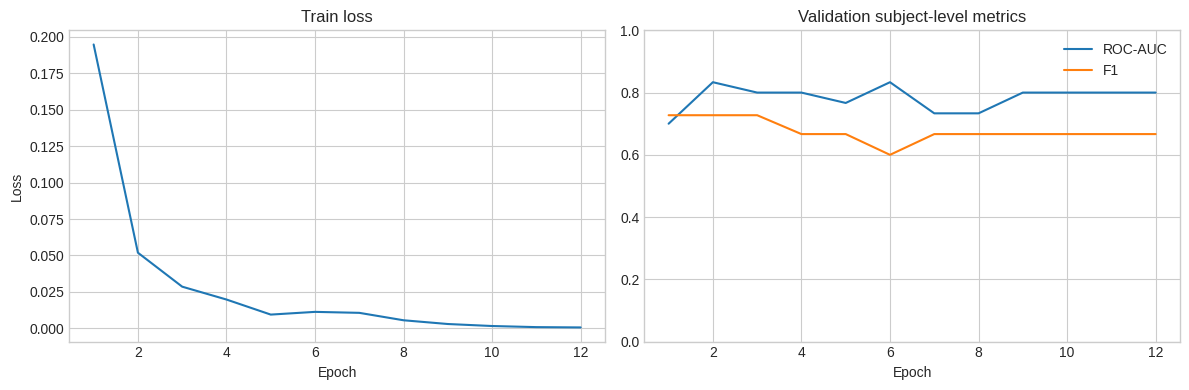

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_df['epoch'], history_df['train_loss'])
axes[0].set_title('Train loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')

axes[1].plot(history_df['epoch'], history_df['val_roc_auc'], label='ROC-AUC')
axes[1].plot(history_df['epoch'], history_df['val_f1'], label='F1')
axes[1].set_title('Validation subject-level metrics')
axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()


## 12. Đánh giá trên test set subject-level

Đây là kết quả chính của notebook ResNet/CNN cho split train/validation/test hiện tại.


In [12]:
test_metrics, test_subject_predictions = evaluate_model(model, test_loader)
pd.DataFrame([test_metrics], index=[f'resnet_cnn_{SELECTED_PROBLEM}'])


,roc_auc,accuracy,f1,sensitivity,specificity
resnet_cnn_ad_hc,0.880952,0.923077,0.923077,0.857143,1.0


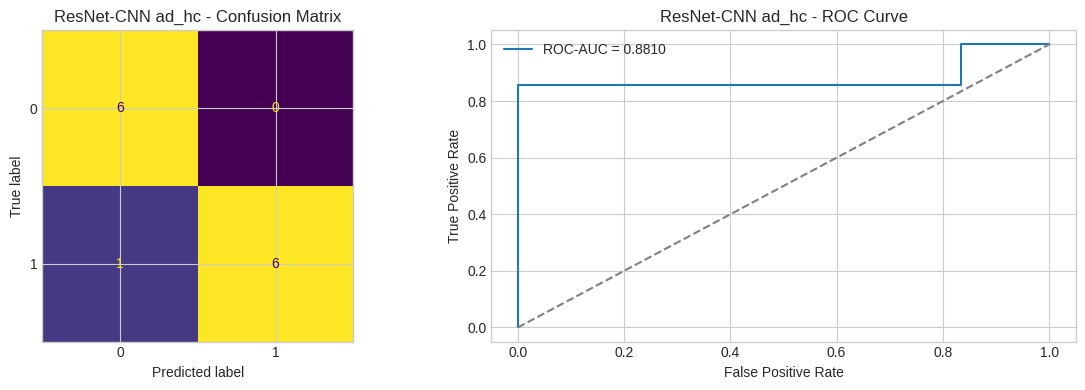

In [13]:
y_true = test_subject_predictions['y_true'].to_numpy()
y_prob = test_subject_predictions['y_prob'].to_numpy()
y_pred = (y_prob >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=axes[0], colorbar=False)
axes[0].set_title(f'ResNet-CNN {SELECTED_PROBLEM} - Confusion Matrix')

fpr, tpr, _ = roc_curve(y_true, y_prob)
axes[1].plot(fpr, tpr, label=f"ROC-AUC = {test_metrics['roc_auc']:.4f}")
axes[1].plot([0, 1], [0, 1], '--', color='gray')
axes[1].set_title(f'ResNet-CNN {SELECTED_PROBLEM} - ROC Curve')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()


## 13. Lưu kết quả ResNet/CNN

Output được lưu riêng để so sánh với notebook `FgMDM + stacking`.


In [14]:
metrics_path = OUTPUT_DIR / f'{OUTPUT_TAG}_{SELECTED_PROBLEM}_resnet_cnn_metrics.csv'
predictions_path = OUTPUT_DIR / f'{OUTPUT_TAG}_{SELECTED_PROBLEM}_resnet_cnn_subject_predictions.csv'
history_path = OUTPUT_DIR / f'{OUTPUT_TAG}_{SELECTED_PROBLEM}_resnet_cnn_history.csv'

pd.DataFrame([test_metrics], index=[f'resnet_cnn_{SELECTED_PROBLEM}']).to_csv(metrics_path)
test_subject_predictions.to_csv(predictions_path, index=False)
history_df.to_csv(history_path, index=False)

print('Da luu:')
print(' -', metrics_path)
print(' -', predictions_path)
print(' -', history_path)


Da luu:
 - /home/dohaidang/DataMining_Project/notebook_outputs/ad_hc_resnet_cnn_metrics.csv
 - /home/dohaidang/DataMining_Project/notebook_outputs/ad_hc_resnet_cnn_subject_predictions.csv
 - /home/dohaidang/DataMining_Project/notebook_outputs/ad_hc_resnet_cnn_history.csv


## 14. Chạy ResNet-CNN cho cả 3 bài toán nhị phân

Phần này đóng gói toàn bộ flow train/evaluate thành hàm để chạy thêm:
- `ad_hc`
- `ftd_hc`
- `ftd_ad`

Mỗi bài toán vẫn chia `train/validation/test` theo subject, chuẩn hóa theo train set, train ResNet-CNN với early stopping, rồi lưu kết quả riêng vào `notebook_outputs/`.


In [ ]:
RESNET_PROBLEMS_TO_RUN = ['ad_hc', 'ftd_hc', 'ftd_ad']
USE_CACHED_RESNET_RESULTS = False


def prepare_problem_split(problem_name: str):
    X_problem, y_problem, s_problem, positive_name, negative_name = make_binary_problem(
        X_all, labels_all, subject_ids_all, problem_name
    )
    subject_table = build_subject_table(y_problem, s_problem)
    train_subjects, val_subjects, test_subjects = split_subjects(subject_table)

    X_train, y_train, s_train = subset_by_subjects(X_problem, y_problem, s_problem, train_subjects['subject_id'])
    X_val, y_val, s_val = subset_by_subjects(X_problem, y_problem, s_problem, val_subjects['subject_id'])
    X_test, y_test, s_test = subset_by_subjects(X_problem, y_problem, s_problem, test_subjects['subject_id'])

    channel_mean = X_train.mean(axis=(0, 2, 3), keepdims=True)
    channel_std = X_train.std(axis=(0, 2, 3), keepdims=True) + 1e-6
    X_train = (X_train - channel_mean) / channel_std
    X_val = (X_val - channel_mean) / channel_std
    X_test = (X_test - channel_mean) / channel_std

    return {
        'problem_name': problem_name,
        'positive_name': positive_name,
        'negative_name': negative_name,
        'subject_table': subject_table,
        'train_subjects': train_subjects,
        'val_subjects': val_subjects,
        'test_subjects': test_subjects,
        'train': (X_train, y_train, s_train),
        'val': (X_val, y_val, s_val),
        'test': (X_test, y_test, s_test),
    }


def train_resnet_cnn_for_problem(problem_name: str, verbose: bool = True):
    set_seed(RANDOM_STATE)
    split = prepare_problem_split(problem_name)
    X_train, y_train, s_train = split['train']
    X_val, y_val, s_val = split['val']
    X_test, y_test, s_test = split['test']

    train_loader = make_loader(X_train, y_train, s_train, BATCH_SIZE, balanced=True)
    val_loader = make_loader(X_val, y_val, s_val, BATCH_SIZE)
    test_loader = make_loader(X_test, y_test, s_test, BATCH_SIZE)

    pos_count = int(y_train.sum())
    neg_count = int(len(y_train) - pos_count)
    pos_weight = torch.tensor([neg_count / max(pos_count, 1)], dtype=torch.float32, device=DEVICE)

    model = ConnectivityResNet(in_channels=len(SELECTED_FEATURES), dropout=DROPOUT).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)

    history = []
    best_auc = -np.inf
    best_state = None
    patience_counter = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_losses = []
        for X_batch, y_batch, _ in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        val_metrics, _ = evaluate_model(model, val_loader)
        scheduler.step(val_metrics['roc_auc'])
        row = {'epoch': epoch, 'train_loss': float(np.mean(train_losses)), **{f'val_{k}': v for k, v in val_metrics.items()}}
        history.append(row)

        if val_metrics['roc_auc'] > best_auc:
            best_auc = val_metrics['roc_auc']
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if verbose:
            print(
                f"{problem_name} | epoch {epoch:03d} | "
                f"loss={row['train_loss']:.4f} | "
                f"val_auc={val_metrics['roc_auc']:.4f} | "
                f"val_f1={val_metrics['f1']:.4f}"
            )

        if patience_counter >= PATIENCE:
            if verbose:
                print(f'{problem_name} | early stopping')
            break

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    test_metrics, test_predictions = evaluate_model(model, test_loader)

    return {
        'problem_name': problem_name,
        'metrics': test_metrics,
        'predictions': test_predictions,
        'history': history_df,
        'split': split,
    }


def resnet_result_paths(problem_name: str):
    return {
        'metrics': OUTPUT_DIR / f'{OUTPUT_TAG}_{problem_name}_resnet_cnn_metrics.csv',
        'predictions': OUTPUT_DIR / f'{OUTPUT_TAG}_{problem_name}_resnet_cnn_subject_predictions.csv',
        'history': OUTPUT_DIR / f'{OUTPUT_TAG}_{problem_name}_resnet_cnn_history.csv',
    }


def load_or_train_resnet_problem(problem_name: str):
    paths = resnet_result_paths(problem_name)
    if USE_CACHED_RESNET_RESULTS and all(path.exists() for path in paths.values()):
        metrics = pd.read_csv(paths['metrics'], index_col=0).iloc[0].to_dict()
        predictions = pd.read_csv(paths['predictions'])
        history = pd.read_csv(paths['history'])
        print(f'Loaded cached ResNet-CNN result: {problem_name}')
        return {'problem_name': problem_name, 'metrics': metrics, 'predictions': predictions, 'history': history}

    result = train_resnet_cnn_for_problem(problem_name, verbose=True)
    paths['metrics'].parent.mkdir(exist_ok=True)
    pd.DataFrame([result['metrics']], index=[f'resnet_cnn_{problem_name}']).to_csv(paths['metrics'])
    result['predictions'].to_csv(paths['predictions'], index=False)
    result['history'].to_csv(paths['history'], index=False)
    print(f'Saved ResNet-CNN result: {problem_name}')
    return result


## 15. Thực thi 3 bài toán và tổng hợp kết quả

Cell này sẽ chạy các bài toán chưa có cache. Nếu đã có file kết quả, nó sẽ đọc lại để vẽ nhanh.


In [ ]:
resnet_all_results = {}
for problem_name in RESNET_PROBLEMS_TO_RUN:
    resnet_all_results[problem_name] = load_or_train_resnet_problem(problem_name)

resnet_metrics_summary = pd.DataFrame({
    problem_name: result['metrics']
    for problem_name, result in resnet_all_results.items()
}).T
resnet_metrics_summary.index.name = 'problem'
resnet_metrics_summary.loc['mean'] = resnet_metrics_summary.mean(numeric_only=True)
resnet_metrics_summary


In [ ]:
resnet_summary_path = OUTPUT_DIR / f'{OUTPUT_TAG}_all_binary_resnet_cnn_metrics_summary.csv'
resnet_metrics_summary.to_csv(resnet_summary_path)
print('Da luu bang tong hop ResNet-CNN:', resnet_summary_path)


## 16. Biểu đồ so sánh ResNet-CNN giữa 3 bài toán

Biểu đồ này dùng để so sánh nhanh mô hình deep learning bổ sung trên 3 bài toán.


In [ ]:
problem_labels = {
    'ad_hc': 'AD vs HC',
    'ftd_hc': 'FTD vs HC',
    'ftd_ad': 'FTD vs AD',
}
plot_metrics = ['roc_auc', 'accuracy', 'f1', 'sensitivity', 'specificity']

ax = resnet_metrics_summary.drop(index='mean')[plot_metrics].rename(index=problem_labels).plot(
    kind='bar', figsize=(12, 5), ylim=(0, 1), width=0.8
)
ax.set_title('So sánh ResNet-CNN trên 3 bài toán nhị phân')
ax.set_xlabel('Bài toán')
ax.set_ylabel('Score')
ax.legend(loc='lower right', ncol=2)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (problem_name, result) in zip(axes, resnet_all_results.items()):
    predictions = result['predictions'].copy()
    predictions['y_pred'] = (predictions['y_prob'] >= 0.5).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        predictions['y_true'], predictions['y_pred'], ax=ax, colorbar=False
    )
    ax.set_title(problem_labels[problem_name])
plt.tight_layout()
plt.show()


## 17. Ghi chú báo cáo

Nên trình bày mô hình này như một baseline deep learning bổ sung:

`Residual CNN nhận multi-channel connectivity matrices làm input, được đánh giá subject-level bằng cách average xác suất epoch của cùng một subject.`

Không nên thay thế kết quả chính LOSOCV bằng kết quả split train/test của notebook này, vì paper sử dụng LOSOCV nghiêm ngặt hơn.
